In [7]:
# Tesseract is pre-installed on Kaggle! import os import pytesseract import
import cv2
import os
!tesseract --version 
input_path ='/kaggle/input/datasets/anderianisar/ai-lab-5'

print('Available files:', os.listdir(input_path))

tesseract 4.1.1
 leptonica-1.82.0
  libgif 5.1.9 : libjpeg 8d (libjpeg-turbo 2.1.1) : libpng 1.6.37 : libtiff 4.3.0 : zlib 1.2.11 : libwebp 1.2.2 : libopenjp2 2.4.0
 Found AVX2
 Found AVX
 Found FMA
 Found SSE
 Found libarchive 3.6.0 zlib/1.2.11 liblzma/5.2.5 bz2lib/1.0.8 liblz4/1.9.3 libzstd/1.4.8
Available files: ['boxes', 'images', 'annotations.xml', 'receipts.csv']


In [9]:
!pip install easyocr -q import easyocr reader = easyocr.Reader(['en'])
print('EasyOCR ready!')

/bin/bash: -c: line 1: syntax error near unexpected token `('
/bin/bash: -c: line 1: `pip install easyocr -q import easyocr reader = easyocr.Reader(['en'])'
EasyOCR ready!


#%% md
# PART 1: TESSERACT OCR


#%% md
## Task 1.1: Basic Text Extraction


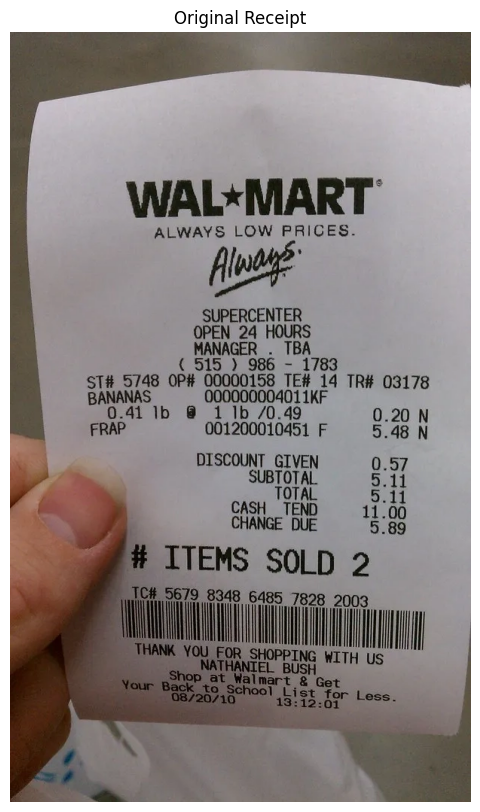

=== EXTRACTED TEXT ===
 

WAL*MART

ALWAYS LOW PRICES.

oe

   

SUPERCENTER
OPEN 24 HOURS
MANAGER . TBA
( 515 ) 986 - 1783
ST# 5748 OP# 00000158 TE# 14 TRH 03178
BANANAS 00000000401 1KF
0.41 Ib @ 1 Ib /0.49 0.20 N
FRAP 001200010451 F 5.48 N
DISCOUNT GIVEN 0.57
5 SUBIQIA. 8.11
5.
y CASH TEND 1100
CHANGE DUE “5 “@g

  



In [1]:
import pytesseract
from PIL import Image
import matplotlib.pyplot as plt

# Path to image (Kaggle)
img_path = '/kaggle/input/datasets/anderianisar/ai-lab-5/images/0.jpg'

# Load image
img = Image.open(img_path)

# Display image
plt.figure(figsize=(8, 10))
plt.imshow(img)   # ✅ FIXED (use img, not path)
plt.title('Original Receipt')
plt.axis('off')
plt.show()

# Extract text using OCR
text = pytesseract.image_to_string(img)

print('=== EXTRACTED TEXT ===')
print(text)

#%% md
## Task 1.2: Get Confidence Scores


In [2]:
import pandas as pd
import pytesseract
from PIL import Image

# Load image
img_path = '/kaggle/input/datasets/anderianisar/ai-lab-5/images/0.jpg'
img = Image.open(img_path)

# Get OCR data with confidence
data = pytesseract.image_to_data(img, output_type=pytesseract.Output.DICT)

# Convert to DataFrame
df = pd.DataFrame(data)

# Clean & filter valid text entries
df = df[df['text'].notna()]                 # remove NaN
df = df[df['text'].str.strip() != '']       # remove empty strings
df['conf'] = df['conf'].astype(float)       # ensure numeric
df = df[df['conf'] != -1]                   # remove invalid confidence

# Display results
print('=== CONFIDENCE SCORES ===')
print(df[['text', 'conf']].head(20))

print(f"\nAverage Confidence: {df['conf'].mean():.1f}%")
print(f"Words detected: {len(df)}")


=== CONFIDENCE SCORES ===
           text  conf
8      WAL*MART  90.0
12       ALWAYS  96.0
13          LOW  96.0
14      PRICES.  96.0
18           oe  61.0
26  SUPERCENTER  89.0
28         OPEN  93.0
29           24  93.0
30        HOURS  96.0
32      MANAGER  79.0
33            .  79.0
34          TBA  94.0
36            (  90.0
37          515  39.0
38            )  39.0
39          986  92.0
40            -  90.0
41         1783  96.0
43          ST#  11.0
44         5748  76.0

Average Confidence: 72.2%
Words detected: 57


#%% md
# PART 2: EASYOCR 


#%% md
## Task 2.1: Initialize EasyOCR


In [3]:
import easyocr

# Initialize reader (downloads models first time)
reader = easyocr.Reader(['en'])

print('EasyOCR initialized!')

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


EasyOCR initialized!


In [4]:
# Set custom directory
reader = easyocr.Reader(
    ['en'],
    model_storage_directory='easyocr_models',  # local folder
    download_enabled=True
)

print("Models stored in ./easyocr_models")


Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


URLError: <urlopen error [Errno -3] Temporary failure in name resolution>

#%% md
## Task 2.2: Extract Text with EasyOCR 


In [5]:
# Read text from image
result = reader.readtext(img_path)

# Display results with confidence
print('=== EasyOCR RESULTS ===')

for detection in result:
    bbox, text, confidence = detection
    print(f'Text: {text:20s} | Confidence: {confidence:.2f}')

# Extract just the text
extracted_text = ' '.join([detection[1] for detection in result])

print('\n=== FULL EXTRACTED TEXT ===')
print(extracted_text)

# Sort text top-to-bottom
result_sorted = sorted(result, key=lambda x: x[0][0][1])

lines = [text for (_, text, _) in result_sorted]
print('\n'.join(lines))

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


=== EasyOCR RESULTS ===
Text: WALAMART             | Confidence: 0.40
Text: ALWAYS               | Confidence: 1.00
Text: Low PRICES_          | Confidence: 0.95
Text: Alwane               | Confidence: 0.32
Text: SUPERCENTER          | Confidence: 0.84
Text: OPEN 24 HOURS        | Confidence: 0.66
Text: MANAGER              | Confidence: 1.00
Text: TBA                  | Confidence: 1.00
Text: 515                  | Confidence: 1.00
Text: 986                  | Confidence: 1.00
Text: 1783                 | Confidence: 1.00
Text: ST# 5748 OP# 00000158 TEIL14 TR# 03178 | Confidence: 0.31
Text: BANANAS              | Confidence: 0.99
Text: OOOOOOOO4011KF       | Confidence: 0.53
Text: 0.41                 | Confidence: 1.00
Text: Ib                   | Confidence: 1.00
Text: 0                    | Confidence: 1.00
Text: 1 Ib /0.49           | Confidence: 0.90
Text: 0.20                 | Confidence: 1.00
Text: FRAP                 | Confidence: 1.00
Text: 001200010451         | Confidenc

#%% md
# PART 3: IMAGE PREPROCESSING 


#%% md
## Task 3.1: Grayscale Conversion


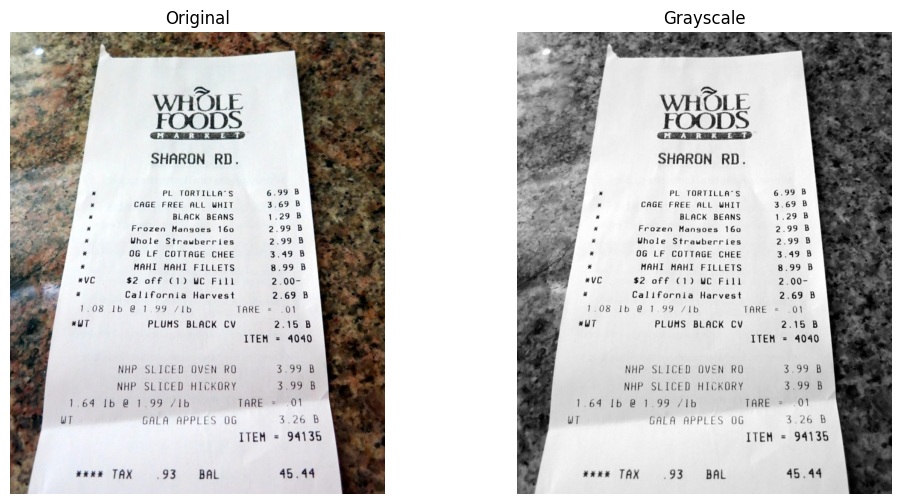

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# KAGGLE path
img_path = '/kaggle/input/datasets/anderianisar/ai-lab-5/images/11.jpg'

# COLAB alternative
# img_path = 'receipt1.jpg'

# Load image
img = cv2.imread(img_path)

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Display comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(gray, cmap='gray')
axes[1].set_title('Grayscale')
axes[1].axis('off')

plt.show()

#%% md
## Task 3.2: Noise Reduction 


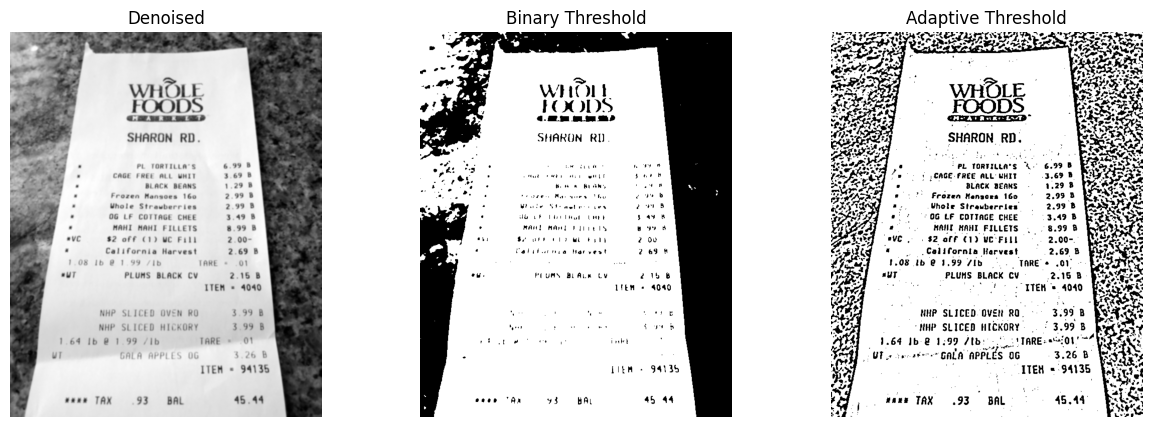

In [7]:
# Recreate missing variable FIRST
denoised = cv2.GaussianBlur(gray, (5, 5), 0)

# Binary thresholding
_, binary = cv2.threshold(denoised, 127, 255, cv2.THRESH_BINARY)

# Adaptive thresholding (better for varying lighting)
adaptive = cv2.adaptiveThreshold(
    denoised,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    11,
    2
)

# Compare all three
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(denoised, cmap='gray')
axes[0].set_title('Denoised')

axes[1].imshow(binary, cmap='gray')
axes[1].set_title('Binary Threshold')

axes[2].imshow(adaptive, cmap='gray')
axes[2].set_title('Adaptive Threshold')

for ax in axes:
    ax.axis('off')

plt.show()

In [ ]:
#%% md
# PART 4: COMPARE OCR RESULTS 


In [8]:
# OCR on original image
text_original = pytesseract.image_to_string(
    Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
)

# OCR on preprocessed image
text_preprocessed = pytesseract.image_to_string(
    Image.fromarray(adaptive)
)

# Print results
print('=== ORIGINAL IMAGE ===')
print(text_original)
print(f'Characters: {len(text_original)}')

print('\n=== PREPROCESSED IMAGE ===')
print(text_preprocessed)
print(f'Characters: {len(text_preprocessed)}')

# Compute improvement safely
improvement = len(text_preprocessed) - len(text_original)

max_len = max(len(text_original), 1)  # avoid division by zero

print(f'\nImprovement: {improvement:+d} chars')
print(f'Percentage: {(improvement / max_len) * 100:.1f}%')

=== ORIGINAL IMAGE ===
WHOLE
FOODS

SHARON RD.

PL TORTILLA’S 6.

CAGE FREE ALL WHIT 3
BLACK BEANS 1

Frozen Mangoes 160 2
Whole Strawberries 2
0G LF COTTAGE CHEE s
8

2

2

MAHI MAHI FILLETS
$2 off (1) WC Fill
California Harvest

1.08 Ib @ 1.99 /Ib

*UT

TARE =
PLUMS BLACK CV 2.

ITEM =

NHP SLICED OVEN RO
NHP SLICED HICKORY
1°64) The eo2e71b TARE 01

UT GALA APPLES OG 3.26 B

ITEM = 94135

 

45.44

Characters: 382

=== PREPROCESSED IMAGE ===
  
   
       
      

_ SHARON RD.

   

“PL TORTILEATS \-

  

         
 
   
  

. 6.99 B

| | {CAGE FREE ALL: WHIT 3,69 8

. BLACK BEANS 1,29 8

Frozen Hensora 160 2.99 8

Uhote Steauberries, 2.99 B

OG LF COTTAGE CHEE 3.49 B

MANE HAHT FILLETS | 8.99 8

$2 aff C1) WCF ELL. 2.00-.
California Harvest 2.69 B

1.08 tb @ 1,99 Zip .  TARE'* .01
auT PLUHS BLACK CV 2.16 B
ve “he STTEW =, 4040
MHP SLICED OVEN RO. - 3.99. B
“MHP SLICED HICKORY.‘ 3.99 B

       
     
     

© 164 Nb 81299 Mtb TARE
UT recat Gala APPLES OG

  

ITEH = 94135

wane TAX

In [9]:
def compare_ocr_methods(image_path):
    # Load image
    img = cv2.imread(image_path)

    # Preprocess
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    denoised = cv2.GaussianBlur(gray, (5, 5), 0)

    thresh = cv2.adaptiveThreshold(
        denoised,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        11,
        2
    )

    # --- Tesseract OCR ---
    tess_text = pytesseract.image_to_string(Image.fromarray(thresh))

    # --- EasyOCR ---
    easy_result = reader.readtext(image_path)
    easy_text = ' '.join([r[1] for r in easy_result])

    return tess_text, easy_text


# Test function
tess, easy = compare_ocr_methods(img_path)

print(f'Tesseract: {len(tess)} characters')
print(f'EasyOCR: {len(easy)} characters')

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Tesseract: 566 characters
EasyOCR: 427 characters


OCR Receipt Processing Project
1. Project Overview

   
This project focuses on building and evaluating an OCR (Optical Character Recognition) pipeline for extracting text from receipt images. The workflow includes image preprocessing, text extraction using multiple OCR engines, and performance comparison between methods.

3. Objectives
   
To extract text from real-world receipt images using OCR techniques
To improve OCR accuracy through image preprocessing
To compare Tesseract OCR and EasyOCR performance
To evaluate the effect of preprocessing on OCR output quality

5. Dataset Description

Dataset Used :
https://www.kaggle.com/datasets/trainingdatapro/ocr-receipts-text-detection
Receipt images (clean, blurry, and noisy samples)
Formats include JPG images (evaluated from 0 to 4 jpg images)
Data sourced from Kaggle / custom dataset

6. Image Preprocessing Pipeline

4.1 Grayscale Conversion

Converted RGB images to grayscale
Reduced computational complexity
4.2 Noise Reduction

Applied Gaussian blur to reduce image noise
Improved text clarity for OCR models
4.3 Thresholding Techniques

Binary thresholding (fixed threshold)
Adaptive Gaussian thresholding (handles lighting variations)
4.4 Purpose of Preprocessing

Enhance text visibility
Reduce background noise
Improve OCR accuracy

7. OCR Methods Used

5.1 Tesseract OCR

Traditional rule-based OCR engine
Works best on clean and structured text
Requires preprocessing for optimal results
5.2 EasyOCR

Deep learning-based OCR model
More robust to noise and distortion
Performs better on real-world images

8. Implementation Workflow

Step 1: Image Loading

Loaded images using OpenCV
Step 2: Preprocessing

Applied grayscale, denoising, and thresholding

Step 3: OCR Extraction

Extracted text using Tesseract
Extracted text using EasyOCR

Step 4: Comparison

Compared outputs based on character length
Evaluated confidence scores (EasyOCR)

9. Key Experiments

Experiment 1: 

Original vs Preprocessed Image
OCR performed on raw image
OCR performed on enhanced image
Observed improvement in readability

Experiment 2:
OCR Engine Comparison
Tesseract vs EasyOCR outputs compared
EasyOCR performed better on noisy images

10. Observations

Preprocessing signficantly improves OCR accuracy
Adaptive thresholding works better under uneven lighting
EasyOCR is more robust for real-world receipts
Tesseract performs better on clean images

11. Challenges Faced
    
Poor image quality (blur and noise)
Inconsistent OCR outputs
Execution order issues in notebook environment
Variable dependency errors (e.g., undefined variables)

12. Learning Outcomes

10.1 Image Processing Skills

Grayscale conversion
Noise reduction techniques
Thresholding methods

10.2 OCR Understanding

Difference between rule-based and deep learning OCR
Impact of preprocessing on OCR accuracy

10.3 Programming Skills

Debugging runtime errors in notebooks
Writing modular functions
Managing pipeline execution order

10.4 Analytical Skills

Comparing model outputs critically
Evaluating OCR confidence vs text length
Understanding trade-offs between OCR systems

13. Conclusion

The project demonstrates that OCR performance is highly dependent on image preprocessing and model selection. A combination of Tesseract and EasyOCR, along with proper preprocessing, leads to significantly improved text extraction from receipt images.

